# Data Preperation
This series of notebooks helps data scientists to forecast multiple time series by building models based on the time-series profiling, i.e identifying similar consumption profiles and building a specific model for each cluster. 

Clustering profile of time series data helps in defining the best fitting model by understanding in terms of choice of regressors (calendar variables or temperatures), forecasting algorithm (ARIMA vs Exponential smoothing) and train set (one year or just few days of data). 

The steps to clustering time series are the following:
1. Prepare data by understand the structure of the data (cross-sectional vs panel data), build a full time sequence and treating missing values
2. Indentifying intermittent time series vs smooth time series, by following an **enhanced** classification based on the Syntetos–Boylan–Croston (SBC) use of Coefficient of Variation (CV^2), Average Demand Interval (ADI) and Standard Deviation Demand Interval (SDDI) indicators
   1. Smooth, if ADI<1.32, CV^2<0.49
   2. Intermittent, if ADI>=1.32, CV^2<0.49
   3. Erratic, if ADI<1.32, CV^2>=0.49
   4. Lumpy, if ADI>=1.32, CV^2>=0.49
   5. Unforecastable time, if SDDI >= SDDI threshold, CV^2<0.49
   6. Unforecastable quantity, if SDDI >= SDDI threshold, CV^2>=0.49
3. Clustering with K-Means those time-series identified as **smooth**
   
In this notebook you will follow step 1 on data preparation, in particular how to deal with NAs, how to aggregate time series and how to create useful regressors (e.g. calendar variables)

# Summary of tasks
This notebook is to prepare data for time-series profiling.

As a **first step**, you need to understand the type of data you are dealing with. You might have **panel data** or **cross-sectional data**. In statistics and econometrics, panel data or longitudinal data is a collection of data that contains observations about different cross sections (groups or ids) that is assembled over intervals in time and ordered chronologically. 

Examples of groups that may make up panel data series include countries, firms, individuals, or demographic groups. 

Specifically:

| Group or Id     | Time period | Notation   |
| :---        | :---   | :--- |
| 1      | 1       | $Y_{11}$  |
| 1      | 2      | $Y_{12}$  |
| 1      | T       | $Y_{1T}$  |
| $\vdots$ | $\vdots$ | $\vdots$ |
| N      | 1       | $Y_{N1}$  |
| N      | 2      | $Y_{N2}$  |
| N      | T       | $Y_{NT}$  |

If you have a **single time series** it can be thought of as special cases of panel data that has one dimension only (one panel member or individual), it is not useful to run the profiler, since you will have just one profile by default. 

The output of this first step is to:
1. Identify if data are panel or cross-section
2. If panel data, what is the unique-id variable of combination of variables that are repeated along the time series
3. Identify the granularity or frequency of the time series
4. Set the time series variable as a datetime object

As a **second step**, you need to build a full time sequence, merge the data on it to understand if there are missing values in the full time sequence and count the number of NAs

**Finally**, check if there are no duplicated entries, if so you might have got wrong how to identify the unique_id

# Implementation

Load the packages, configuration manager modules and plotting modules

## Packages

In [1]:
# Data elaboration functions
import pandas as pd
import string
import numpy as np
import re
from typing import List, Any, Dict, Union
from pathlib import Path

# Datetime functions
import datetime as dt

# Plot functions
import matplotlib.pyplot as plt
%matplotlib inline

# Spark for Fabric
from pyspark.sql import SparkSession

print("✅ Packages loaded successfully")

✅ Packages loaded successfully


## Inlined Utility Functions
These functions are inlined from the original `Utils` module for Fabric compatibility

In [2]:
# ============================================================
# INLINED UTILITY FUNCTIONS (from Utils.utils)
# ============================================================

def camel_to_snake(name: str) -> str:
    """
    Changes string from camel case to snake case
    :params: a string
    :return: a string
    """
    # Insert underscore before uppercase letters that follow lowercase letters or digits
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    # Insert underscore before uppercase letters that follow other uppercase and precede lowercase
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()


def columns_camel_to_snake(df: pd.DataFrame) -> pd.DataFrame:
    """
    Changes dataframe columns from camel case to snake case
    :params: df as dataframe
    :return: a pandas dataframe
    """
    list_cols = list(df.columns)
    for name in list_cols:
        new_name = camel_to_snake(name)
        df.rename(columns={name: new_name}, inplace=True)
    return df


def add_seq(df: pd.DataFrame, date_var: str, serie: str, freq: str, end_date: str = '', start_date: str = '') -> pd.DataFrame:
    """
    Creates a sequence of complete dates to a dataframe
    :params: dataframe in long format, date_var as string,
        serie or id as string, freq as datetime frequency, end and start date
    :return: a Pandas dataframe with full time sequence
    """
    # Handle timezone-aware dates
    if hasattr(df[date_var].dtype, 'tz') and df[date_var].dtype.tz is not None:
        df.loc[:, date_var] = df[date_var].apply(lambda x: x.tz_localize(None) if hasattr(x, 'tz_localize') else x)

    # Map date_range freq to period freq (MS -> M, etc.)
    # 'MS' (MonthStart) for date_range, but 'M' for to_period()
    period_freq_mapping = {'MS': 'M', 'M': 'M', 'D': 'D', 'H': 'H', 'W': 'W', 'W-SUN': 'W', 'Y': 'Y', 'YS': 'Y', 'Q': 'Q', 'QS': 'Q'}
    period_freq = period_freq_mapping.get(freq, freq)

    seq = pd.DataFrame()
    serie_list = list(df.loc[:, serie].unique())

    for i in serie_list:
        if start_date == '':
            s_date = min(df.loc[df[serie] == i, date_var])
            if hasattr(s_date, 'tz_localize'):
                try:
                    s_date = s_date.tz_localize(None)
                except:
                    pass
        else:
            s_date = pd.to_datetime(start_date, dayfirst=True)
        
        if end_date == '':
            e_date = max(df.loc[df[serie] == i, date_var])
            if hasattr(e_date, 'tz_localize'):
                try:
                    e_date = e_date.tz_localize(None)
                except:
                    pass
        else:
            e_date = pd.to_datetime(end_date, dayfirst=True)
        
        # Generate time range using freq for date_range, but period_freq for to_period
        time_range = pd.Series(pd.date_range(start=s_date, end=e_date, freq=freq)).dt.to_period(period_freq)
        
        print('Adding sequence to serie', i, 'as', serie_list.index(i) + 1, 'of', len(serie_list))
        temp = pd.DataFrame.from_dict({serie: [i] * len(time_range), 'date': time_range})
        temp.rename(columns={'date': date_var}, inplace=True)
        seq = pd.concat([seq, temp], axis=0, ignore_index=True)
    
    # Check for duplicates
    duplicates = seq.loc[:, [serie, date_var]].duplicated().any()
    if duplicates:
        raise Exception("add_seq: there are duplicates in sequence")
    else:
        print("add_seq: there are NO duplicates in sequence")
    
    print('Total series to forecast:', len(seq.loc[:, [serie, date_var]].drop_duplicates()))
    
    return seq


def check_length_time_serie(df: pd.DataFrame, date_var: str, index: str, freq: Union[str, None] = None) -> pd.DataFrame:
    """
    Checks the length that a time sequence should have
    :params: df as pandas dataframe, date_var as string, index as groupby variable
    :return: a Pandas dataframe
    """
    pivot = pd.pivot_table(df, index=index, values=date_var, aggfunc=['count', 'min', 'max']).reset_index()
    pivot.columns = pivot.columns.get_level_values(0)
    pivot.loc[:, 'count'] = pivot.loc[:, 'count'].astype(float)
    
    # Use provided freq (or fall back to the notebook-level `frequency` variable)
    freq = freq or globals().get('frequency')
    if freq is None:
        print('check_length_time_serie: no frequency provided; cannot compute expected_obs')
        pivot.loc[:, 'expected_obs'] = np.nan
        return pivot[[index, 'count', 'expected_obs']].drop_duplicates()
    
    # Map common frequencies to pandas date_range-compatible ones
    freq_mapping = {
        'M': 'MS', 'MS': 'MS',
        'D': 'D',
        'H': 'H',
        'W': 'W', 'W-SUN': 'W-SUN',
        'Y': 'YS', 'YS': 'YS',
        'Q': 'QS', 'QS': 'QS',
    }
    dr_freq = freq_mapping.get(freq, freq)
    pivot.loc[:, 'freq'] = freq
    pivot.loc[:, 'expected_obs'] = pivot.apply(
        lambda row: len(pd.date_range(start=row['min'], end=row['max'], freq=dr_freq)), axis=1
    )
    pivot.loc[:, 'mismatch'] = (pivot['count'] != pivot['expected_obs']).astype(int)
    
    if sum(pivot.mismatch) > 0:
        print('Expected length of sequence is NOT OK')
    else:
        print('Expected length of sequence is OK')
    
    return pivot[[index, 'count', 'expected_obs']].drop_duplicates()


print("✅ Utility functions loaded")

✅ Utility functions loaded


### ✅ CHECK POINT with the data scientist: confirm configuration parameters
In this Fabric notebook, configuration values are inlined (instead of `config.yaml`). Confirm the date column, target column, unique_id definition, and frequency before proceeding.

### ✅ CHECK POINT with the data scientist: parameters
Configuration values are inlined (instead of config.yaml). Confirm these parameters with the data scientist.

In [ ]:
# ============================================================
# CONFIGURATION PARAMETERS (inlined from config.yaml)
# ============================================================

# Time series configuration
date_var = 'WEEK_START_DT'  # Date variable name after renaming
date_format = '%Y-%m-%d'  # Date format
id = 'STORE_LOCATION_ID'  # ID variable name
unique_id = 'STORE_LOCATION_ID'  # Unique ID variable name
list_unique_id = ['STORE_LOCATION_ID', 'REGION']  # List of unique ID variables
frequency = 'W'  # Weekly frequency
y = 'TOTAL_NET_SALES'  # Target variable name

# Fabric Lakehouse configuration
LAKEHOUSE_NAME = "ts_forecasting"
INPUT_TABLE = "df_raw"
OUTPUT_TABLE = "df_final"
LOCAL_FOLDER = "supermarket_net_sales"  # Local folder for fallback storage

root_path = Path.cwd().parent.parent

print("📋 Configuration loaded:")
print(f"  - Date variable: {date_var}")
print(f"  - Unique ID: {unique_id}")
print(f"  - Target variable: {y}")
print(f"  - Frequency: {frequency}")
print(f"  - Input table: {LAKEHOUSE_NAME}.{INPUT_TABLE}")
print(f"  - Output table: {LAKEHOUSE_NAME}.{OUTPUT_TABLE}")

📋 Configuration loaded:
  - Date variable: WEEK_START_DT
  - Unique ID: STORE_LOCATION_ID
  - Target variable: TOTAL_NET_SALES
  - Frequency: W
  - Input table: ts_forecasting.simulated_demand_data
  - Output table: ts_forecasting.df_final


## Load Data
Load data from Lakehouse table instead of CSV file

In [ ]:
# ============================================================
# LOAD DATA FROM LAKEHOUSE
# ============================================================

# Read from Lakehouse table using Spark, then convert to Pandas
try:
    df_spark = spark.table(f"{LAKEHOUSE_NAME}.{INPUT_TABLE}")
    df = df_spark.toPandas()
except:
    print(f"❌ Error loading data from {LAKEHOUSE_NAME}.{INPUT_TABLE}, loading from local file instead.")
    root_path = Path.cwd().parent.parent
    df = pd.read_parquet(f"{root_path}/data/df_raw.parquet")  # Fallback to local file if Lakehouse load fails

print(f"✅ Loaded {len(df)} rows")
print(df.head())

❌ Error loading data from ts_forecasting.simulated_demand_data, loading from local file instead.
✅ Loaded 5200 rows
   STORE_LOCATION_ID WEEK_START_DT  TOTAL_NET_SALES  STORE_SELLING_AREA_SQFT  \
0                  1    2023-04-06    522814.849132                    32653   
1                  1    2023-04-13    620024.491881                    32653   
2                  1    2023-04-20    623209.751040                    32653   
3                  1    2023-04-27    641359.169727                    32653   
4                  1    2023-05-04    615285.571504                    32653   

   NEARBY_COMPETITOR_STORE_COUNT  COMPETITOR_PREMIUM_A_PRESENT  \
0                              2                             0   
1                              2                             0   
2                              2                             0   
3                              2                             0   
4                              2                             0   

   COM

### Defining and formatting as date the date variable

In [5]:
# The source column is 'ds', we need to convert and rename to 'date'
df.loc[:, 'date_converted'] = pd.to_datetime(df.loc[:, date_var], format=date_format)
df.drop(columns=[date_var], inplace=True)
df.rename(columns={'date_converted': date_var}, inplace=True)

# Reorder columns
df.ordered_columns = [unique_id, date_var, y] + [col for col in df.columns if col not in [unique_id, date_var, y]]
df = df.reindex(columns=df.ordered_columns)
df.head()

C:\Users\mabellani\AppData\Local\Temp\ipykernel_64816\781841338.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.ordered_columns = [unique_id, date_var, y] + [col for col in df.columns if col not in [unique_id, date_var, y]]


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-06,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-13,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-20,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-27,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-04,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### ✅ CHECK POINT with the data scientist: check missing values
Check number of columns and NaNs before generating full time sequences

In [6]:
print("Df columns: ", list(df.columns))
print("NaNs:", df.isna().sum().values.sum())

Df columns:  ['STORE_LOCATION_ID', 'WEEK_START_DT', 'TOTAL_NET_SALES', 'STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'SPEND_TV', 'SPEND_RADIO', 'SPEND_OOH', 'SPEND_META', 'SPEND_TIKTOK', 'SPEND_PINTEREST', 'SPEND_DV360', 'SPEND_GOOGLE_SEARCH', 'SPEND_GEO_SEARCH_DISPLAY', 'SPEND_GEO_SOCIAL', 'SPEND_DIGITAL_FLYER', 'SPEND_INSTORE_SIGNAGE', 'VOLUME_EMAILS_SENT', 'VOLUME_FLYER_COPIES', 'VOLUME_INSTORE_DIGITAL_IMPRESSIONS', 'VOLUME_APP_VIEWS', 'VOLUME_WEB_VIEWS', 'VOLUME_EMAILS_VIEWED', 'VOLUME_PERSO_EMAILS_SENT', 'VOLUME_PERSO_EMAILS_VIEWED', 'DISCOUNT_FLYER', 'DISCOUNT_MEMBER_PRICING', 'AVG_COMPETITIVE_PRICE_INDEX', 'AVG_SERVICE_GAP_RATIO', 

# Data Preparation
Create a full time sequence on a chosen frequency and aggregate. To create a full time sequence, you need:

1. The unique_id that identifies the time-series, for example if a product is sold in different store, the unique_id will be product_store
2. The frequency (e.g. daily) 
3. The earliest date and the latest available for each unique_id

Then a function generate a full time sequence from earliest to latest date at the given frequency. On that full time sequence, the data are merged so that is it clear how many effective missing data are present.

In demand forecasting, you may consider missing data as zero, meaning zero demand for that specific date time.

## Dealing with NAs by creating a full time sequence and aggregating at a chosen frequency

### ✅ CHECK POINT with the data scientist: list unique_id
You may ask the data scientist if the number of unique_ids is as expected

In [7]:
print('List ids:', list(df[unique_id].unique()))
len(list(df[unique_id].unique()))

List ids: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


50

## Creating a full time sequence

### ✅ CHECK POINT with the data scientist: check the frequency of the time series
Check the frequency

In [8]:
print("Frequency is", frequency)

Frequency is W


### Create a sequence of dates

In [9]:
# Map common frequencies to pandas date_range-compatible ones
# - Use 'MS' (Month Start) for monthly
# - Use 'QS'/'YS' for quarter/year starts
freq_mapping = {'M': 'MS', 'MS': 'MS', 'D': 'D', 'H': 'H', 'W': 'W', 'W-SUN': 'W-SUN', 'Q': 'QS', 'QS': 'QS', 'Y': 'YS', 'YS': 'YS'}
pandas_freq = freq_mapping.get(frequency, frequency)

df_seq = add_seq(df, date_var=date_var, serie=unique_id, freq=pandas_freq, end_date='', start_date='')

Adding sequence to serie 1 as 1 of 50
Adding sequence to serie 2 as 2 of 50
Adding sequence to serie 3 as 3 of 50
Adding sequence to serie 4 as 4 of 50
Adding sequence to serie 5 as 5 of 50
Adding sequence to serie 6 as 6 of 50
Adding sequence to serie 7 as 7 of 50
Adding sequence to serie 8 as 8 of 50
Adding sequence to serie 9 as 9 of 50
Adding sequence to serie 10 as 10 of 50
Adding sequence to serie 11 as 11 of 50
Adding sequence to serie 12 as 12 of 50
Adding sequence to serie 13 as 13 of 50
Adding sequence to serie 14 as 14 of 50
Adding sequence to serie 15 as 15 of 50
Adding sequence to serie 16 as 16 of 50
Adding sequence to serie 17 as 17 of 50
Adding sequence to serie 18 as 18 of 50
Adding sequence to serie 19 as 19 of 50
Adding sequence to serie 20 as 20 of 50
Adding sequence to serie 21 as 21 of 50
Adding sequence to serie 22 as 22 of 50
Adding sequence to serie 23 as 23 of 50
Adding sequence to serie 24 as 24 of 50
Adding sequence to serie 25 as 25 of 50
Adding sequence to

In [10]:
df_seq.head()

,STORE_LOCATION_ID,WEEK_START_DT
0,1,2023-04-03/2023-04-09
1,1,2023-04-10/2023-04-16
2,1,2023-04-17/2023-04-23
3,1,2023-04-24/2023-04-30
4,1,2023-05-01/2023-05-07


## Merge full time sequence with df
Use a left 1:1 merge on the df with the full time sequence, so that if there are no data on df, you will have a missing value

In [11]:
df.loc[:, date_var] = df.loc[:, date_var].dt.to_period(frequency)
df.head()

C:\Users\mabellani\AppData\Local\Temp\ipykernel_64816\2422474197.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<PeriodArray>
['2023-04-03/2023-04-09', '2023-04-10/2023-04-16', '2023-04-17/2023-04-23',
 '2023-04-24/2023-04-30', '2023-05-01/2023-05-07', '2023-05-08/2023-05-14',
 '2023-05-15/2023-05-21', '2023-05-22/2023-05-28', '2023-05-29/2023-06-04',
 '2023-06-05/2023-06-11',
 ...
 '2025-01-20/2025-01-26', '2025-01-27/2025-02-02', '2025-02-03/2025-02-09',
 '2025-02-10/2025-02-16', '2025-02-17/2025-02-23', '2025-02-24/2025-03-02',
 '2025-03-03/2025-03-09', '2025-03-10/2025-03-16', '2025-03-17/2025-03-23',
 '2025-03-24/2025-03-30']
Length: 5200, dtype: period[W-SUN]' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.loc[:, date_var] = df.loc[:, date_var].dt.to_period(frequency)


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03/2023-04-09,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10/2023-04-16,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17/2023-04-23,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24/2023-04-30,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01/2023-05-07,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df_time_sequence = pd.merge(df_seq, df, on=[unique_id, date_var], how='left', validate='1:1')
df_time_sequence.head()

,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03/2023-04-09,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10/2023-04-16,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17/2023-04-23,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24/2023-04-30,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01/2023-05-07,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
df_time_sequence.loc[:, date_var] = df_time_sequence.loc[:, date_var].apply(lambda x: x.to_timestamp())
df_time_sequence.head()

C:\Users\mabellani\AppData\Local\Temp\ipykernel_64816\1174772801.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<DatetimeArray>
['2023-04-03 00:00:00', '2023-04-10 00:00:00', '2023-04-17 00:00:00',
 '2023-04-24 00:00:00', '2023-05-01 00:00:00', '2023-05-08 00:00:00',
 '2023-05-15 00:00:00', '2023-05-22 00:00:00', '2023-05-29 00:00:00',
 '2023-06-05 00:00:00',
 ...
 '2025-01-13 00:00:00', '2025-01-20 00:00:00', '2025-01-27 00:00:00',
 '2025-02-03 00:00:00', '2025-02-10 00:00:00', '2025-02-17 00:00:00',
 '2025-02-24 00:00:00', '2025-03-03 00:00:00', '2025-03-10 00:00:00',
 '2025-03-17 00:00:00']
Length: 5150, dtype: datetime64[ns]' has dtype incompatible with period[W-SUN], please explicitly cast to a compatible dtype first.
  df_time_sequence.loc[:, date_var] = df_time_sequence.loc[:, date_var].apply(lambda x: x.to_timestamp())


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## Count the number of obs you should have if you had a full time sequence

#### ✅ CHECK POINT with the data scientist: count the number of observations per id you have
This function count the number of obs you should have if you had a full time sequence

In [14]:
check_length_time_serie(df_time_sequence, date_var, index=unique_id, freq=frequency).head()

Expected length of sequence is NOT OK


,STORE_LOCATION_ID,count,expected_obs
0,1,103,102
1,2,103,102
2,3,103,102
3,4,103,102
4,5,103,102


In [15]:
df_time_sequence.head()

,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### List ids after resampling and adding full time sequence

In [16]:
print('List ids after resampling and adding full time sequence:', list(df_time_sequence[unique_id].unique()))

List ids after resampling and adding full time sequence: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


# Plots
Visualize the time series data

In [17]:
number_of_ids_to_plot: int = len(list(df_time_sequence[unique_id].unique()))
print('Number of ids to plot:', number_of_ids_to_plot)

Number of ids to plot: 50


In [18]:
list_ids_to_plot = list(df_time_sequence[unique_id].unique())
print("Ids to plot: ", list_ids_to_plot[:5], "... (showing first 5)")

Ids to plot:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] ... (showing first 5)


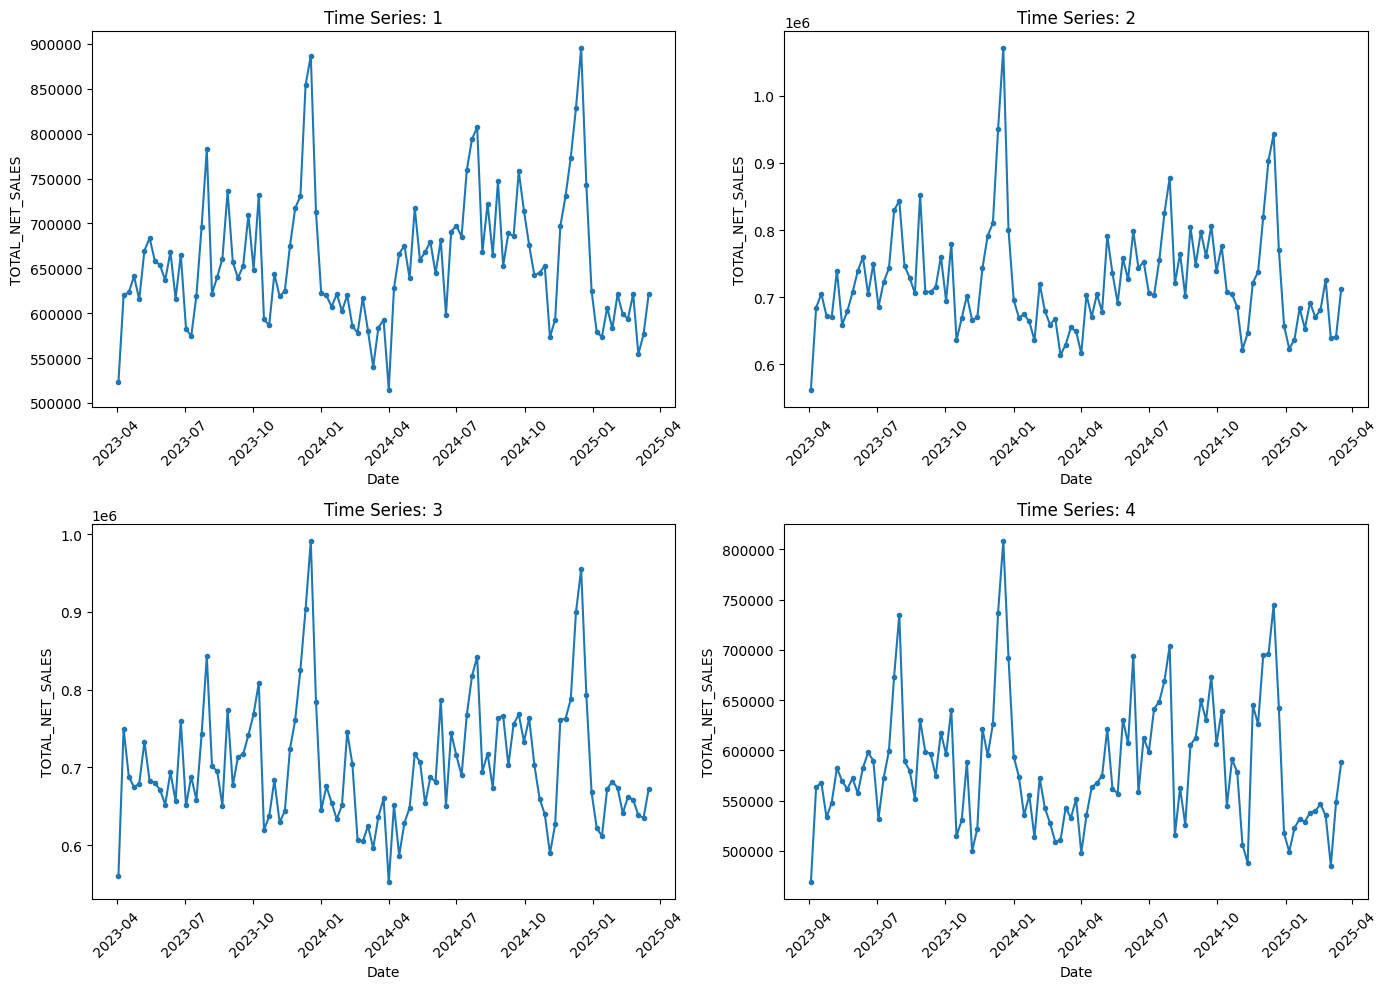

✅ Plotted 4 sample time series


In [19]:
# Simple matplotlib plot for a sample of time series
# (Replacing the Plotly-based Plots class for Fabric compatibility)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sample_ids = list_ids_to_plot[:4]  # Plot first 4 time series

for idx, ts_id in enumerate(sample_ids):
    ts_data = df_time_sequence[df_time_sequence[unique_id] == ts_id].sort_values(date_var)
    axes[idx].plot(ts_data[date_var], ts_data[y], marker='o', markersize=3)
    axes[idx].set_title(f'Time Series: {ts_id}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel(y)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"✅ Plotted {len(sample_ids)} sample time series")

# Count NAs in y by unique_id
Count the number of NAs of the target variable by unique_id

In [20]:
df_time_sequence.head()

,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# Count NAs by unique_id
na_counts = df_time_sequence[df_time_sequence[y].isna()].groupby(unique_id).size().reset_index(name=f'{y}_count_NA')

if len(na_counts) > 0:
    print("NAs found by unique_id:")
    print(na_counts)
else:
    print("✅ No NAs found in target variable!")

✅ No NAs found in target variable!


# ✅ CHECK POINT with the data scientist: always check for duplicate values
Remove duplicates: always check for the presence of duplicate values, if there are most probably you did something wrong in identifying the unique_id

In [22]:
df_final = df_time_sequence.drop_duplicates()
print('List ids in df_final after removing duplicates:', list(df_final[unique_id].unique()))
assert df_final[df_final.duplicated()].count().sum() == 0, "y should not contain duplicates"
print('Min date:', df_final[date_var].min())
print('Max date:', df_final[date_var].max())

List ids in df_final after removing duplicates: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]
Min date: 2023-04-03 00:00:00
Max date: 2025-03-17 00:00:00


# Saving
Save the dataframe to Lakehouse table instead of CSV file

In [ ]:
# ============================================================
# SAVE TO LAKEHOUSE TABLE
# ============================================================
try:
# Convert pandas DataFrame to Spark DataFrame and save as Delta table
    df_final_spark = spark.createDataFrame(df_final)
    df_final_spark.write.mode("overwrite").saveAsTable(f"{LAKEHOUSE_NAME}.{OUTPUT_TABLE}")

    print(f"✅ df_final saved to: {LAKEHOUSE_NAME}.{OUTPUT_TABLE}")
except:
    df_final.to_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{OUTPUT_TABLE}.parquet")

print(f"Rows: {len(df_final)}, Columns: {len(df_final.columns)}")
print('🔍 Min date:', df_final[date_var].min())
print('🔍 Max date:', df_final[date_var].max())
df_final.head()

Rows: 5150, Columns: 95
🔍 Min date: 2023-04-03 00:00:00
🔍 Max date: 2025-03-17 00:00:00


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
